In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

import threading
from concurrent.futures import ThreadPoolExecutor

ROOT = Path().resolve().parents[1]
sys.path.append(str(ROOT / "src"))

from forward import magcal
from forward.thread_func import thread_func

### SC-TLI
L1-L2 penalty in the space domain and structural coupling in the temporal domain

$$
P(\boldsymbol{\beta}) = 
\lambda_s \left( \alpha \left\| \boldsymbol{\beta} \right\|_1 + \frac{1 - \alpha}{2} \| \boldsymbol{\beta} \|_2^2 \right)
+
\lambda_t \sum_{\mathcal{G}_j} \left\| \left( \boldsymbol{D} \boldsymbol{\beta} \right)_{\mathcal{G}_j} \right\|_2
$$

In [ ]:
from inversion.SCTLI import ADMMGroupLasso

In [4]:
# data misfit
def misfit(f, K, beta):
    return 0.5 * np.linalg.norm(f - K.dot(beta))**2

# penalty
def pen1(beta, alpha):
    return alpha * np.linalg.norm(beta, ord=1) + (1 - alpha) * 0.5 * np.linalg.norm(beta)**2
    
def pen2(Dbeta, num_of_cells, times):
    pen2 = 0
    for k in range(num_of_cells):
        temp = 0
        for j in range(times-1):
            temp += Dbeta[k + j*num_of_cells]**2
        pen2 += np.sqrt(temp)
    return pen2

In [5]:
# curvature
def calcCurvature2(x,y):
    
    dif_x = np.gradient(x)
    dif_y = np.gradient(y)
    dif2_x = np.gradient(dif_x)
    dif2_y = np.gradient(dif_y)
    
    curvature = np.abs(dif2_x * dif_y - dif_x * dif2_y) / (dif_x **2 + dif_y **2)**1.5
    return curvature

### Model domain

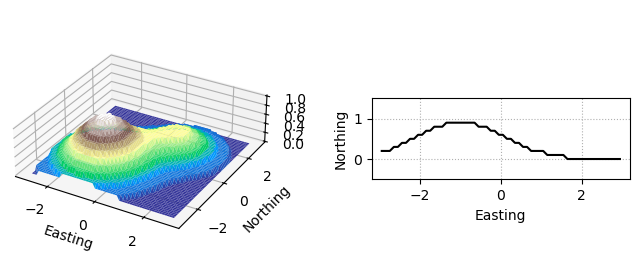

In [6]:
### Creation of subsurface grid: xgrd, ygrd, zgrd ###
# incx, incy, incz : grid spacing in the x, y, and z directions
incx = 0.1
incy = 0.1
incz = 0.1

x = np.arange(-3.0 + 0.5*incx, 3.0, incx)
y = np.arange(-3.0 + 0.5*incy, 3.0, incy)
nx = len(x)
ny = len(y)

# Two hills (northeast and southwest)
from scipy.ndimage import gaussian_filter

X, Y = np.meshgrid(x, y)

# Northeast hill
A1 = 0.5
x1, y1 = 1.0, 1.0
sigma1 = 1.25
z1 = A1 * np.exp(-((X - x1)**2 + (Y - y1)**2) / sigma1**2)

# Southwest hill
A2 = 1.0
x2, y2 = -1.0, -1.0
sigma2 = 1.5
z2 = A2 * np.exp(-((X - x2)**2 + (Y - y2)**2) / sigma2**2)

# Combined topography
T = z1 + z2

# Round to 0.1 increments
T = np.round(T / 0.1) * 0.1

### Creation of subsurface grid: xgrd, ygrd, zgrd ###
# Number of subsurface layers = 30  # 60×60×30
nz = 30
[yy2, zz2, xx2] = np.meshgrid(y, np.zeros(nz), x)

for k in range(nz):
    for i in range(nx):
        for j in range(ny):
            zz2[k, j, i] = T.reshape(-1)[i + nx*j] - incz / 2. - incz*k
            
xgrd = xx2.reshape(-1)
ygrd = yy2.reshape(-1)
zgrd = zz2.reshape(-1)

# For visualization
xfig, yfig, zfig = [], [], []

for i in range(len(xgrd)):
    j = i // (nx*ny)
    
    # Store coordinates of the 8 vertices of each grid cell
    xfig.append([xgrd[i] - 0.5*incx, xgrd[i] + 0.5*incx, xgrd[i] - 0.5*incx, xgrd[i] + 0.5*incx, 
                 xgrd[i] - 0.5*incx, xgrd[i] + 0.5*incx, xgrd[i] - 0.5*incx, xgrd[i] + 0.5*incx])
    yfig.append([ygrd[i] - 0.5*incy, ygrd[i] - 0.5*incy, ygrd[i] + 0.5*incy, ygrd[i] + 0.5*incy, 
                 ygrd[i] - 0.5*incy, ygrd[i] - 0.5*incy, ygrd[i] + 0.5*incy, ygrd[i] + 0.5*incy])
    zfig.append([zgrd[i] - 0.5*incz, zgrd[i] - 0.5*incz, zgrd[i] - 0.5*incz, zgrd[i] - 0.5*incz, 
                 zgrd[i] + 0.5*incz, zgrd[i] + 0.5*incz, zgrd[i] + 0.5*incz, zgrd[i] + 0.5*incz])

# Convert to arrays
xfig = np.array(xfig)
yfig = np.array(yfig)
zfig = np.array(zfig)

# dim: block size
dim = [[incx / 2., incx / 2.], [incy / 2., incy / 2.], [incz / 2., incz / 2.]]

# Near Tokyo
# Declination (degrees)
dec = -7.
# Inclination (degrees)
inc = 50.

# Visualization
fig = plt.figure(figsize = (8, 4))
plt.subplots_adjust(wspace=0.4, hspace=0.)

ax = fig.add_subplot(121, projection='3d')
ax.plot_surface(X, Y, T, rstride=1, cstride=1, cmap = plt.cm.terrain)
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")
ax.set_box_aspect((1,1,0.3))

ax = fig.add_subplot(122)
ys = 15
ax.plot(X[ys, :], T[ys,:], color = "black")
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")
ax.set_aspect("equal")
ax.set_xlim(-3.2, 3.2)
ax.set_ylim(-0.5, 1.5)
ax.grid(linestyle = "dotted")

Text(0.5, 1.0, 'NE–SW Cross-section (No Interpolation)')

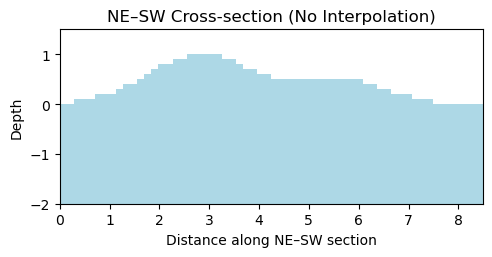

In [7]:
from matplotlib.patches import Rectangle

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(122)

tol = 0.05   # Section width (adjust as needed)

# Cross-section (NE–SW)
for i in range(len(xgrd)):

    # 8 vertices of the voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE–SW section condition: y ≈ x ---
    # Center of the voxel
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # Distance axis along the section (southwest → northeast)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Draw rectangle (no interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor="lightblue", edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

# Axis settings
ax.set_xlim(0, np.sqrt( (3 - (-3))**2 * 2 ))  # Diagonal distance
ax.set_ylim(-2.0, 1.5)
ax.set_aspect("equal")
ax.set_xlabel("Distance along NE–SW section")
ax.set_ylabel("Depth")
ax.set_title("NE–SW Cross-section (No Interpolation)")

### Aeromagnetic survey layout（N-S direction, 100 m ASL）

CPU times: total: 13.2 s
Wall time: 13.8 s


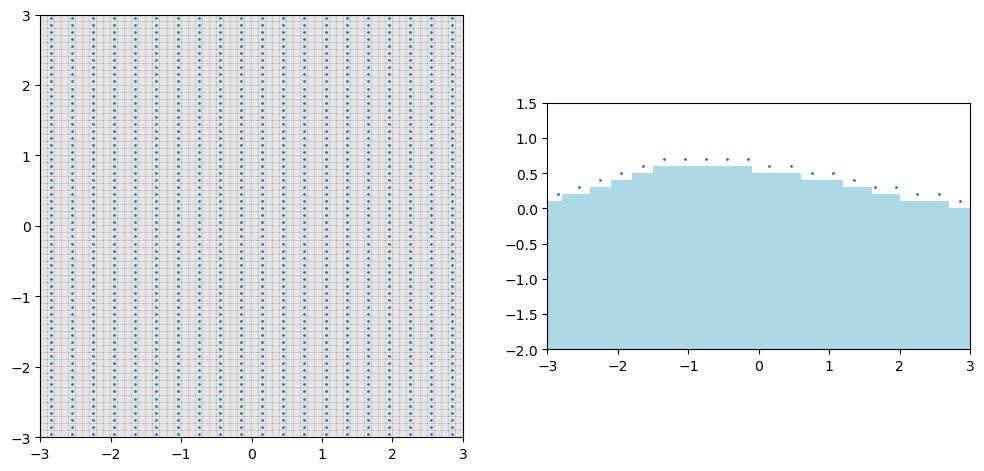

In [8]:
%%time
### Synthetic data generation ###
# Coordinates: x positive eastward, y positive northward, z positive upward

### Observation points: xobs, yobs, zobs ###
[xobs1, yobs1] = np.meshgrid(np.arange(-3.0 + incx + 0.5*incx, 3.0, 3*incx), np.arange(-3.0 + 0.5*incy, 3.0, incy))
xobs1 = xobs1.reshape(-1)
yobs1 = yobs1.reshape(-1)
zobs1 = np.zeros(len(xobs1))

for i in range(len(xobs1)):
    for j in range(len(X.reshape(-1))):
        if (abs(xobs1[i] - X.reshape(-1)[j]) < 1e-3) & (abs(yobs1[i] - Y.reshape(-1)[j]) < 1e-3):
            zobs1[i] = T.reshape(-1)[j] + 0.1 # 100 m above the surface

# Visualization
from matplotlib import cm
from matplotlib.colors import Normalize
import matplotlib.colorbar as clb
from matplotlib import gridspec
from matplotlib.patches import Rectangle

fig = plt.figure(figsize = (12, 6))

ax = fig.add_subplot(121)
ax.pcolor(xx2[0,:,:], yy2[0,:,:], np.zeros(xx2[0,:,:].shape), cmap = "gray", alpha = 0.1)
ax.scatter(xobs1, yobs1, s = 1)
ax.set_aspect("equal")

ax = fig.add_subplot(122)

ax.scatter(xobs1[(0<yobs1)&(yobs1<incy)], zobs1[(0<yobs1)&(yobs1<incy)], s = 1)

# Cross-section
for i in range(len(xgrd)):
    
    # Coordinates
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # Condition
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # Width and height of the rectangular prism
        width  = x_max - x_min
        height = z_max - z_min

        # Draw rectangle
        rect = Rectangle((x_min, z_min), width, height, facecolor="lightblue", edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-2.0, 1.5)
ax.set_aspect("equal")

### Aeromagnetic survey layout（E-W direction, 100 m ASL）

CPU times: total: 12.6 s
Wall time: 12.8 s


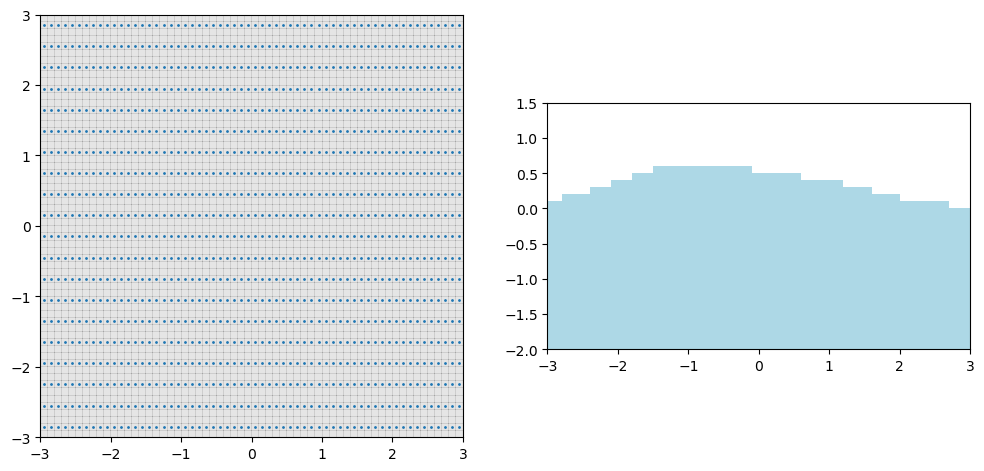

In [9]:
%%time
### Synthetic data generation ###
# Coordinates: x positive eastward, y positive northward, z positive upward

### Observation points: xobs, yobs, zobs ###
[xobs2, yobs2] = np.meshgrid(np.arange(-3.0 + 0.5*incx, 3.0, incx), np.arange(-3.0 + incx + 0.5*incy, 3.0, 3*incy))
xobs2 = xobs2.reshape(-1)
yobs2 = yobs2.reshape(-1)
zobs2 = np.zeros(len(xobs2))

for i in range(len(xobs2)):
    for j in range(len(X.reshape(-1))):
        if (abs(xobs2[i] - X.reshape(-1)[j]) < 1e-3) & (abs(yobs2[i] - Y.reshape(-1)[j]) < 1e-3):
            zobs2[i] = T.reshape(-1)[j] + 0.1 # 100 m above the surface

# Visualization
from matplotlib import cm
from matplotlib.colors import Normalize
import matplotlib.colorbar as clb
from matplotlib import gridspec
from matplotlib.patches import Rectangle

fig = plt.figure(figsize = (12, 6))

ax = fig.add_subplot(121)
ax.pcolor(xx2[0,:,:], yy2[0,:,:], np.zeros(xx2[0,:,:].shape), cmap = "gray", alpha = 0.1)
ax.scatter(xobs2, yobs2, s = 1)
ax.set_aspect("equal")

ax = fig.add_subplot(122)

ax.scatter(xobs2[(0<yobs2)&(yobs2<incy)], zobs2[(0<yobs2)&(yobs2<incy)], s = 1)

# Cross-section
for i in range(len(xgrd)):
    
    # Coordinates
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # Condition
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # Width and height of the rectangular prism
        width  = x_max - x_min
        height = z_max - z_min

        # Draw rectangle
        rect = Rectangle((x_min, z_min), width, height, facecolor="lightblue", edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-2.0, 1.5)
ax.set_aspect("equal")

### Aeromagnetic survey layout（N-S direction, 60 m ASL）

CPU times: total: 12.8 s
Wall time: 13.2 s


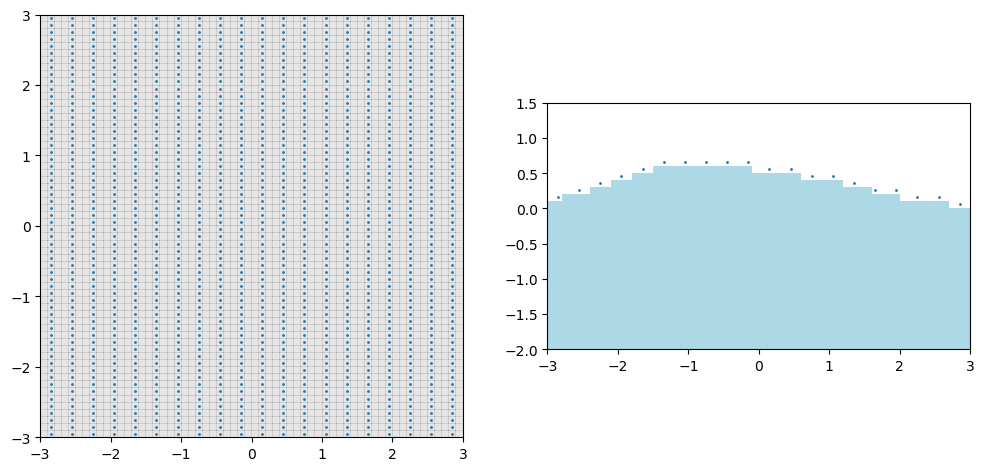

In [10]:
%%time
### Synthetic data generation ###
# Coordinates: x positive eastward, y positive northward, z positive upward

### Observation points: xobs, yobs, zobs ###
[xobs3, yobs3] = np.meshgrid(np.arange(-3.0 + incx + 0.5*incx, 3.0, 3*incx), np.arange(-3.0 + 0.5*incy, 3.0, incy))
xobs3 = xobs3.reshape(-1)
yobs3 = yobs3.reshape(-1)
zobs3 = np.zeros(len(xobs3))

for i in range(len(xobs3)):
    for j in range(len(X.reshape(-1))):
        if (abs(xobs3[i] - X.reshape(-1)[j]) < 1e-3) & (abs(yobs3[i] - Y.reshape(-1)[j]) < 1e-3):
            zobs3[i] = T.reshape(-1)[j] + 0.06 # 60 m above the surface

# Visualization
from matplotlib import cm
from matplotlib.colors import Normalize
import matplotlib.colorbar as clb
from matplotlib import gridspec
from matplotlib.patches import Rectangle

fig = plt.figure(figsize = (12, 6))

ax = fig.add_subplot(121)
ax.pcolor(xx2[0,:,:], yy2[0,:,:], np.zeros(xx2[0,:,:].shape), cmap = "gray", alpha = 0.1)
ax.scatter(xobs3, yobs3, s = 1)
ax.set_aspect("equal")

ax = fig.add_subplot(122)

ax.scatter(xobs3[(0<yobs3)&(yobs3<incy)], zobs3[(0<yobs3)&(yobs3<incy)], s = 1)

# Cross-section
for i in range(len(xgrd)):
    
    # Coordinates
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # Condition
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # Width and height of the rectangular prism
        width  = x_max - x_min
        height = z_max - z_min

        # Draw rectangle
        rect = Rectangle((x_min, z_min), width, height, facecolor="lightblue", edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-2.0, 1.5)
ax.set_aspect("equal")

### Aeromagnetic survey layout（E-W direction, 50 m ASL）

CPU times: total: 14.6 s
Wall time: 15.2 s


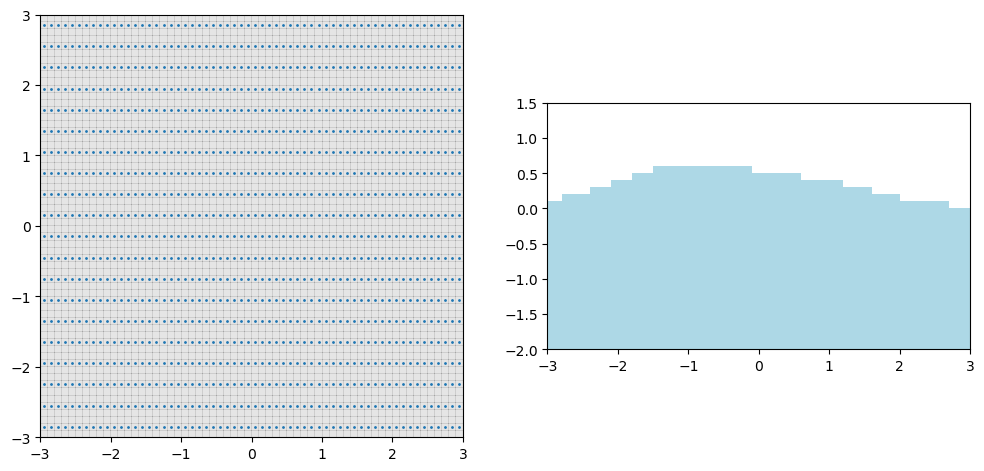

In [11]:
%%time
### Synthetic data generation ###
# Coordinates: x positive eastward, y positive northward, z positive upward

### Observation points: xobs, yobs, zobs ###
[xobs4, yobs4] = np.meshgrid(np.arange(-3.0 + 0.5*incx, 3.0, incx), np.arange(-3.0 + incx + 0.5*incy, 3.0, 3*incy))
xobs4 = xobs4.reshape(-1)
yobs4 = yobs4.reshape(-1)
zobs4 = np.zeros(len(xobs4))

for i in range(len(xobs4)):
    for j in range(len(X.reshape(-1))):
        if (abs(xobs4[i] - X.reshape(-1)[j]) < 1e-3) & (abs(yobs4[i] - Y.reshape(-1)[j]) < 1e-3):
            zobs4[i] = T.reshape(-1)[j] + 0.05 # 50 m above the surface

# Visualization
from matplotlib import cm
from matplotlib.colors import Normalize
import matplotlib.colorbar as clb
from matplotlib import gridspec
from matplotlib.patches import Rectangle

fig = plt.figure(figsize = (12, 6))

ax = fig.add_subplot(121)
ax.pcolor(xx2[0,:,:], yy2[0,:,:], np.zeros(xx2[0,:,:].shape), cmap = "gray", alpha = 0.1)
ax.scatter(xobs4, yobs4, s = 1)
ax.set_aspect("equal")

ax = fig.add_subplot(122)

ax.scatter(xobs4[(0<yobs4)&(yobs4<incy)], zobs4[(0<yobs4)&(yobs4<incy)], s = 1)

# Cross-section
for i in range(len(xgrd)):
    
    # Coordinates
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # Condition
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # Width and height of the rectangular prism
        width  = x_max - x_min
        height = z_max - z_min

        # Draw rectangle
        rect = Rectangle((x_min, z_min), width, height, facecolor="lightblue", edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-2.0, 1.5)
ax.set_aspect("equal")

### Kernel matrix

In [ ]:
%%time
# Compute the kernel matrix using parallel processing with threading
# Create unit vector
mgz = magcal.di2xyz(dec = dec, inc = inc)
exf = mgz.copy()

# Number of threads (number of parallel workers)
n = 12

# Divide the computation range i = [0, nz] into n segments
p = np.linspace(0, nz - 1, n).astype(int)
p[-1] += 1
print(p)

# Store return values from each thread in the ThreadPool
results = []

pool = ThreadPoolExecutor(max_workers=n-1)
for i in range(n - 1):
    p0 = p[i]
    p1 = p[i + 1]
    res = pool.submit(thread_func, p0, p1, mgz, xobs1, yobs1, zobs1, xgrd, ygrd, zgrd, dim, 1000.)
    results.append(res)

pool.shutdown()

# Retrieve results and stack them to construct the final kernel matrix
K1 = []
for res in results:
    Ki = res.result()
    if len(K1) == 0:
        K1 = Ki.copy()
    else:
        K1 = np.hstack((K1, Ki))

In [ ]:
%%time
# Compute the kernel matrix using parallel processing with threading
# Create unit vector
mgz = magcal.di2xyz(dec = dec, inc = inc)
exf = mgz.copy()

# Number of threads (number of parallel workers)
n = 12

# Divide the computation range i = [0, nz] into n segments
p = np.linspace(0, nz - 1, n).astype(int)
p[-1] += 1
print(p)

# Store return values from each thread in the ThreadPool
results = []

pool = ThreadPoolExecutor(max_workers=n-1)
for i in range(n - 1):
    p0 = p[i]
    p1 = p[i + 1]
    res = pool.submit(thread_func, p0, p1, mgz, xobs2, yobs2, zobs2, xgrd, ygrd, zgrd, dim, 1000.)
    results.append(res)

pool.shutdown()

# Retrieve results and stack them to construct the final kernel matrix
K2 = []
for res in results:
    Ki = res.result()
    if len(K2) == 0:
        K2 = Ki.copy()
    else:
        K2 = np.hstack((K2, Ki))

In [ ]:
%%time
# Compute the kernel matrix using parallel processing with threading
# Create unit vector
mgz = magcal.di2xyz(dec = dec, inc = inc)
exf = mgz.copy()

# Number of threads (number of parallel workers)
n = 12

# Divide the computation range i = [0, nz] into n segments
p = np.linspace(0, nz - 1, n).astype(int)
p[-1] += 1
print(p)

# Store return values from each thread in the ThreadPool
results = []

pool = ThreadPoolExecutor(max_workers=n-1)
for i in range(n - 1):
    p0 = p[i]
    p1 = p[i + 1]
    res = pool.submit(thread_func, p0, p1, mgz, xobs3, yobs3, zobs3, xgrd, ygrd, zgrd, dim, 1000.)
    results.append(res)

pool.shutdown()

# Retrieve results and stack them to construct the final kernel matrix
K3 = []
for res in results:
    Ki = res.result()
    if len(K3) == 0:
        K3 = Ki.copy()
    else:
        K3 = np.hstack((K3, Ki))

In [ ]:
%%time
# Compute the kernel matrix using parallel processing with threading
# Create unit vector
mgz = magcal.di2xyz(dec = dec, inc = inc)
exf = mgz.copy()

# Number of threads (number of parallel workers)
n = 12

# Divide the computation range i = [0, nz] into n segments
p = np.linspace(0, nz - 1, n).astype(int)
p[-1] += 1
print(p)

# Store return values from each thread in the ThreadPool
results = []

pool = ThreadPoolExecutor(max_workers=n-1)
for i in range(n - 1):
    p0 = p[i]
    p1 = p[i + 1]
    res = pool.submit(thread_func, p0, p1, mgz, xobs4, yobs4, zobs4, xgrd, ygrd, zgrd, dim, 1000.)
    results.append(res)

pool.shutdown()

# Retrieve results and stack them to construct the final kernel matrix
K4 = []
for res in results:
    Ki = res.result()
    if len(K4) == 0:
        K4 = Ki.copy()
    else:
        K4 = np.hstack((K4, Ki))

In [13]:
# Depth weighting
w1 = np.linalg.norm(K1, axis=0)
X1 = K1 / w1

# Depth weighting
w2 = np.linalg.norm(K2, axis=0)
X2 = K2 / w2

# Depth weighting
w3 = np.linalg.norm(K3, axis=0)
X3 = K3 / w3

# Depth weighting
w4 = np.linalg.norm(K4, axis=0)
X4 = K4 / w4

CPU times: total: 4.33 s
Wall time: 4.36 s


### Input models

Text(0.5, 1.0, 'fobs4 (nT)')

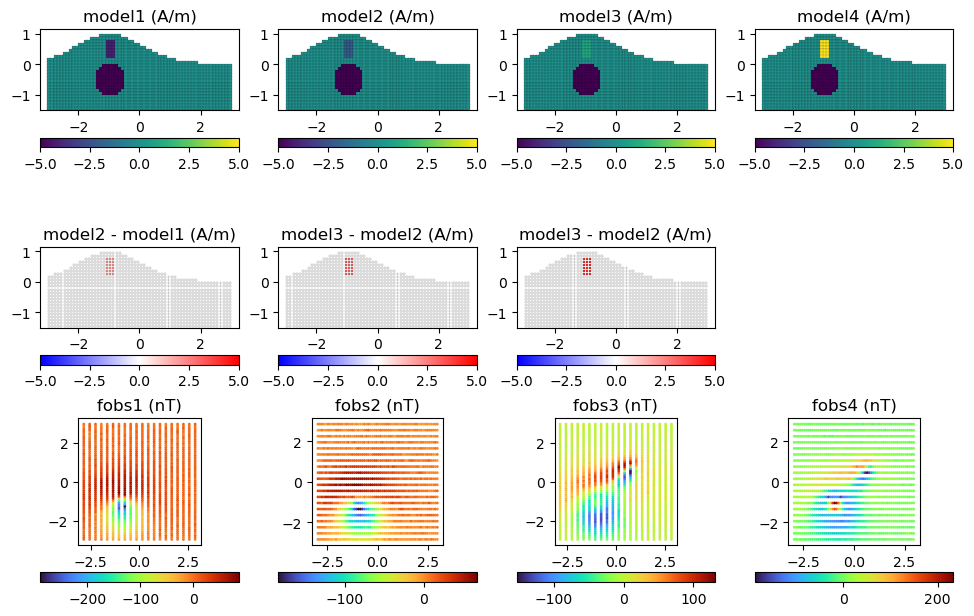

In [14]:
### Magnetization structure  ###

# Spherical demagnetized source  
zcenter = -0.5
a_rad = 0.5
b_rad = 0.5
c_rad = 0.5

# Lateral dike intrusion
# Direction vector (NE + 30° upward)
d = np.array([
    np.cos(np.deg2rad(10)) / np.sqrt(2),
    np.cos(np.deg2rad(10)) / np.sqrt(2),
    np.sin(np.deg2rad(10))
])  # Normalized

# Center
center = np.array([-0.95, -0.95, -0.2])

# Dike radius
dike_r = 0.1

# Vector from grid points to the dike reference point
dx = xx2 - center[0]
dy = yy2 - center[1]
dz = zz2 - center[2]

# Axial distance t (projection)
t = dx * d[0] + dy * d[1] + dz * d[2]

# Distance from the axis
px = center[0] + t * d[0]
py = center[1] + t * d[1]
pz = center[2] + t * d[2]

dist_axis = np.sqrt((xx2 - px)**2 + (yy2 - py)**2 + (zz2 - pz)**2)

# ------------------------------------------------------------ #
### Time1 ###
beta1 = 0 * np.ones(len(xgrd))
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if (xgrd[k] - center[0])**2 / a_rad**2 + (ygrd[k] - center[1])**2 / b_rad**2 + (zgrd[k] - zcenter)**2 / c_rad**2 <= 1:
                beta1[k] = -5

# Dike 1
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if ((xgrd[k] - center[0])**2 + (ygrd[k] - center[1])**2 <= 0.15**2) & (0.2 <= zgrd[k]) & (zgrd[k] <= 0.8):
                beta1[k] = -4

### Time2 ###
beta2 = 0 * np.ones(len(xgrd))
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if (xgrd[k] - center[0])**2 / a_rad**2 + (ygrd[k] - center[1])**2 / b_rad**2 + (zgrd[k] - zcenter)**2 / c_rad**2 <= 1:
                beta2[k] = -5
                
# Dike 1
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if ((xgrd[k] - center[0])**2 + (ygrd[k] - center[1])**2 <= 0.15**2) & (0.2 <= zgrd[k]) & (zgrd[k] <= 0.8):
                beta2[k] = -2
                
### Time3 ###
beta3 = 0 * np.ones(len(xgrd))
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if (xgrd[k] - center[0])**2 / a_rad**2 + (ygrd[k] - center[1])**2 / b_rad**2 + (zgrd[k] - zcenter)**2 / c_rad**2 <= 1:
                beta3[k] = -5

# Dike 1
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if ((xgrd[k] - center[0])**2 + (ygrd[k] - center[1])**2 <= 0.15**2) & (0.2 <= zgrd[k]) & (zgrd[k] <= 0.8):
                beta3[k] = 1

# Dike 2
L3 = 2.6 # Dike length
inside_dike = (dist_axis <= dike_r) & (t >= 0) & (t <= L3)
beta3.reshape(xx2.shape)[inside_dike] = -5

### Time4 ###
beta4 = 0 * np.ones(len(xgrd))
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if (xgrd[k] - center[0])**2 / a_rad**2 + (ygrd[k] - center[1])**2 / b_rad**2 + (zgrd[k] - zcenter)**2 / c_rad**2 <= 1:
                beta4[k] = -5

# Dike 1
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if ((xgrd[k] + - center[0])**2 + (ygrd[k] - center[1])**2 <= 0.15**2) & (0.2 <= zgrd[k]) & (zgrd[k] <= 0.8):
                beta4[k] = 5

# Dike 2
L4 = 2.6 # Dike length
inside_dike = (dist_axis <= dike_r) & (t >= 0) & (t <= L4)
beta4.reshape(xx2.shape)[inside_dike] = -5

# ------------------------------------------------------------ #

# Compute magnetic anomalies
f1_row = K1.dot(beta1)
f2_row = K2.dot(beta2)
f3_row = K3.dot(beta3)
f4_row = K4.dot(beta4)

# Add Gaussian noise
np.random.seed(42)
noise1 = np.random.normal(loc=0, scale=5.0, size=len(f1_row)) # 5 nT
noise2 = np.random.normal(loc=0, scale=5.0, size=len(f2_row)) # 5 nT
noise3 = np.random.normal(loc=0, scale=5.0, size=len(f3_row)) # 5 nT
noise4 = np.random.normal(loc=0, scale=5.0, size=len(f4_row)) # 5 nT
fobs1 = f1_row + noise1
fobs2 = f2_row + noise2
fobs3 = f3_row + noise3
fobs4 = f4_row + noise4

bb1 = beta1.reshape(nz, ny, nx)
bb2 = beta2.reshape(nz, ny, nx)
bb3 = beta3.reshape(nz, ny, nx)
bb4 = beta4.reshape(nz, ny, nx)

<timed exec>:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.


CPU times: total: 15.6 s
Wall time: 15.8 s


Text(0.5, 1.0, 'NE–SW Cross-section (No Interpolation)')

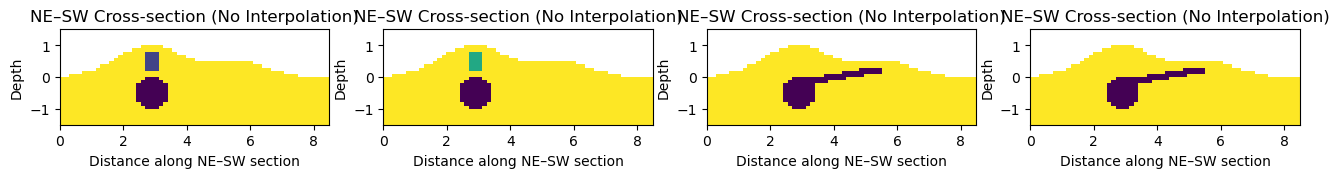

In [15]:
%%time
# Colormap
from matplotlib import cm
cmap = cm.get_cmap("gist_earth")
norm = Normalize(vmin = -100, vmax = 1100)

# Dashed line
# Start and end points
P0 = np.array([-3, -3])
P1 = np.array([3, 3])

# Direction vector and normalization
d = P1 - P0
d_norm = d / np.linalg.norm(d)

# Distance range
t1, t2 = 1.0, 7.0

# Generate points along the line segment
ts = np.linspace(t1, t2, 200)
points = P0 + np.outer(ts, d_norm)


# Visualization
fig = plt.figure(figsize = (14, 12.5))
plt.subplots_adjust(wspace=0.1, hspace=-0.3)

#--- Topography ---#

ax = fig.add_subplot(541)
p = ax.pcolor(X, Y, T*1e3, cmap = cmap)
p.set_clim(-100, 1100)

ax.plot(points[:, 0], points[:, 1], linestyle='--', color='white', linewidth=2)

ax.set_aspect("equal")
ax.set_xlim(-3, )
ax.set_ylim(-3, )
ax.set_xlabel("Easting (km)")
ax.set_ylabel("Northing (km)")
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])
cax = inset_axes(ax,
                 width="85%", 
                 height="10%",
                 loc='lower center',
                 bbox_to_anchor=(0, -0.38, 1, 0.65),
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
cbar.ax.set_title("Topography (m)", fontsize = 12)


#--- Input model ---#

# Colormap
cmap = cm.get_cmap("RdYlBu")
norm = Normalize(vmin = -6, vmax = 6)

# T = T1
ax = fig.add_subplot(5,4,9)

# Cross-section (NE–SW)
for i in range(len(xgrd)):

    # 8 vertices of the voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE–SW section condition: y ≈ x ---
    # Voxel center
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # Distance axis along the section (SW → NE)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Get color based on beta value
        beta_val = beta1[i]
        color = cmap(norm(beta_val))
        
        # Draw rectangle (no interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(0, np.sqrt( (3 - (-3))**2 * 2 ))
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
ax.set_xlabel("Distance along NE–SW (km)")
ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_1$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])
cax = inset_axes(ax,
                 width="85%",
                 height="10%",
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1),
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization (A/m)", fontsize = 12)

# T = T2
ax = fig.add_subplot(5,4,10)

# Cross-section (NE–SW)
for i in range(len(xgrd)):

    # 8 vertices of the voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE–SW section condition: y ≈ x ---
    # Voxel center
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # Distance axis along the section (SW → NE)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Get color based on beta value
        beta_val = beta2[i]
        color = cmap(norm(beta_val))
        
        # Draw rectangle (no interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(0, np.sqrt( (3 - (-3))**2 * 2 ))
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
ax.set_xlabel("Distance along NE–SW (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_2$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, )
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])
cax = inset_axes(ax,
                 width="85%",
                 height="10%",
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1),
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization (A/m)", fontsize = 12)

# T = T_3
ax = fig.add_subplot(5,4,11)

# Cross-section (NE–SW)
for i in range(len(xgrd)):

    # 8 vertices of the voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE–SW section condition: y ≈ x ---
    # Voxel center
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # Distance axis along the section (SW → NE)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Get color based on beta value
        beta_val = beta3[i]
        color = cmap(norm(beta_val))
        
        # Draw rectangle (no interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(0, np.sqrt( (3 - (-3))**2 * 2 ))
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
ax.set_xlabel("Distance along NE–SW (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_3$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, )
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])
cax = inset_axes(ax,
                 width="85%", 
                 height="10%", 
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1),
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization (A/m)", fontsize = 12)

# T = T_4 
ax = fig.add_subplot(5,4,12)

# Cross-section (NE–SW)
for i in range(len(xgrd)):

    # 8 vertices of the voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE–SW section condition: y ≈ x ---
    # Voxel center
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # Distance axis along the section (SW → NE)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Get color based on beta value
        beta_val = beta4[i]
        color = cmap(norm(beta_val))
        
        # Draw rectangle (no interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(0, np.sqrt( (3 - (-3))**2 * 2 ))
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
ax.set_xlabel("Distance along NE–SW (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_4$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, )
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])
cax = inset_axes(ax,
                 width="85%",
                 height="10%",
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1),
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization (A/m)", fontsize = 12)

### data ###

# T = T_1
ax = fig.add_subplot(5,4,17)
p = ax.scatter(xobs1, yobs1, c = fobs1, cmap = "turbo", s = 1)
#plt.colorbar(p)
p.set_clim(-350, 150)
ax.set_aspect("equal")
ax.set_xlabel("Easting (km)")
ax.set_ylabel("Northing (km)")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.set_yticks([-3, -2, -1, 0, 1, 2, 3])
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
cmap = cm.get_cmap("turbo")
norm = Normalize(vmin = -350, vmax = 150)
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])
cax = inset_axes(ax,
                 width="85%",
                 height="10%", 
                 loc='lower center',
                 bbox_to_anchor=(0, -0.38, 1, 0.65), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
cbar.ax.set_title("Magnetic anomaly (nT)", fontsize = 12)

# T = T_2
ax = fig.add_subplot(5,4,18)
p = ax.scatter(xobs2, yobs2, c = fobs2, cmap = "turbo", s = 1)
#plt.colorbar(p)
p.set_clim(-200, 100)
ax.set_aspect("equal")
ax.set_xlabel("Easting (km)")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.set_yticks([-3, -2, -1, 0, 1, 2, 3])
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, )
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
cmap = cm.get_cmap("turbo")
norm = Normalize(vmin = -200, vmax = 100)
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])
cax = inset_axes(ax,
                 width="85%", 
                 height="10%",
                 loc='lower center',
                 bbox_to_anchor=(0, -0.38, 1, 0.65),
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
cbar.ax.set_title("Magnetic anomaly (nT)", fontsize = 12)

# T = T_3
ax = fig.add_subplot(5,4,19)
p = ax.scatter(xobs3, yobs3, c = fobs3, cmap = "turbo", s = 1)
#plt.colorbar(p)
p.set_clim(-200, 150)
ax.set_aspect("equal")
ax.set_xlabel("Easting (km)")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.set_yticks([-3, -2, -1, 0, 1, 2, 3])
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, )
ax.tick_params(width = 1, length = 1)

#--- colorbar ---# 
cmap = cm.get_cmap("turbo")
norm = Normalize(vmin = -200, vmax = 150)
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([]) 
cax = inset_axes(ax,
                 width="85%", 
                 height="10%",
                 loc='lower center',
                 bbox_to_anchor=(0, -0.38, 1, 0.65),
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
cbar.ax.set_title("Magnetic anomaly (nT)", fontsize = 12)

# T = T_4
ax = fig.add_subplot(5,4,20)
p = ax.scatter(xobs4, yobs4, c = fobs4, cmap = "turbo", s = 1)

#plt.colorbar(p)
p.set_clim(-200, 200)
ax.set_aspect("equal")
ax.set_xlabel("Easting (km)")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.set_yticks([-3, -2, -1, 0, 1, 2, 3])
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, )
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
cmap = cm.get_cmap("turbo")
norm = Normalize(vmin = -200, vmax = 200)
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])
cax = inset_axes(ax,
                 width="85%", 
                 height="10%",
                 loc='lower center',
                 bbox_to_anchor=(0, -0.38, 1, 0.65),
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
cbar.ax.set_title("Magnetic anomaly (nT)", fontsize = 12)

### Joint Inversion

In [17]:
# f
fobs = np.r_[fobs1, fobs2, fobs3, fobs4]

In [18]:
# Z
Z = np.r_[np.c_[X1, np.zeros(X1.shape), np.zeros(X1.shape), np.zeros(X1.shape)], 
          np.c_[np.zeros(X2.shape), X2, np.zeros(X2.shape), np.zeros(X2.shape)], 
          np.c_[np.zeros(X3.shape), np.zeros(X3.shape), X3, np.zeros(X3.shape)], 
          np.c_[np.zeros(X4.shape), np.zeros(X4.shape), np.zeros(X4.shape), X4]]

# D
zeros = sp.sparse.diags(np.zeros(len(xgrd)))
D = sp.sparse.vstack([ sp.sparse.hstack([sp.sparse.diags(1 / w1), -sp.sparse.diags(1 / w2), zeros, zeros]), 
                       sp.sparse.hstack([zeros, sp.sparse.diags(1 / w2), -sp.sparse.diags(1 / w3), zeros]),
                       sp.sparse.hstack([zeros, zeros, sp.sparse.diags(1 / w3), -sp.sparse.diags(1 / w4)]),
                     ])

print(Z.shape, fobs.shape, D.shape)

(4800, 432000) (4800,) (324000, 432000)


In [19]:
%%time
# parameter
eta = 1.
rho = 1.

# inverse matrix
inv1 = sp.sparse.linalg.inv(rho * sp.sparse.eye(Z.shape[1]) + eta * D.T * D)
inv2 = np.linalg.inv(np.eye(Z.shape[0]) + Z.dot(inv1 * Z.T))

C:\Users\ri710\anaconda3\envs\pygmt\Lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:603: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
C:\Users\ri710\anaconda3\envs\pygmt\Lib\site-packages\scipy\sparse\linalg\_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)


ok
ok
CPU times: total: 6h 50min 51s
Wall time: 6h 46min 9s


### Step1

In [21]:
# hyper-parameters
lams_s = np.power(10., np.arange(0.0, 2.6, 0.25))
print("lams1 = {}".format(lams_s))

lam_t = 1.0 # fixed

lams1 = [  1.           1.77827941   3.16227766   5.62341325  10.
  17.7827941   31.6227766   56.23413252 100.         177.827941
 316.22776602]


In [22]:
alpha = 0.9
rho = 1.0
eta = 1.0

In [23]:
%%time
params_all = []
betas1_all = []
betas2_all = []
betas3_all = []
betas4_all = []

for lis in range(len(lams_s)):

    params_all.append([lams_s[lis], lam_t])
    print("lm1 = {}, lm2 = {}".format(lams_s[lis], lam_t))

    model = admm_group_lasso(lambda_s = lams_s[lis], lambda_t = lam_t, alpha = alpha, rho = rho, eta = eta, tol = 1.e-3)
    model.fit(fobs, Z, D, inv1, inv2, times = 4, num_of_cells = nx*ny*nz)
    
    beta_sim1 = model.beta_[0*nx*ny*nz:1*nx*ny*nz] / w1
    beta_sim2 = model.beta_[1*nx*ny*nz:2*nx*ny*nz] / w2
    beta_sim3 = model.beta_[2*nx*ny*nz:3*nx*ny*nz] / w3
    beta_sim4 = model.beta_[3*nx*ny*nz:4*nx*ny*nz] / w4

    betas1_all.append(beta_sim1)
    betas2_all.append(beta_sim2)
    betas3_all.append(beta_sim3)
    betas4_all.append(beta_sim4)

# ndarry
params_all = np.array(params_all)
betas1_all = np.array(betas1_all)
betas2_all = np.array(betas2_all)
betas3_all = np.array(betas3_all)
betas4_all = np.array(betas4_all)

lm1 = 1.0, lm2 = 1.0
iter = 0, delta = 0.18840644569583165
fin_i = 56
lm1 = 1.7782794100389228, lm2 = 1.0
iter = 0, delta = 0.23313718272342382
fin_i = 87
lm1 = 3.1622776601683795, lm2 = 1.0
iter = 0, delta = 0.2690773446367532
fin_i = 155
lm1 = 5.623413251903491, lm2 = 1.0
iter = 0, delta = 0.2944147511925045
fin_i = 281
lm1 = 10.0, lm2 = 1.0
iter = 0, delta = 0.3095544593360817
fin_i = 468
lm1 = 17.78279410038923, lm2 = 1.0
iter = 0, delta = 0.31451181446794296
fin_i = 699
lm1 = 31.622776601683793, lm2 = 1.0
iter = 0, delta = 0.3145375846173771
iter = 1000, delta = 0.001160810278274482
fin_i = 1156
lm1 = 56.23413251903491, lm2 = 1.0
iter = 0, delta = 0.3145375846173771
iter = 1000, delta = 0.0024589044278746468
iter = 2000, delta = 0.001181530336958537
fin_i = 2335
lm1 = 100.0, lm2 = 1.0
iter = 0, delta = 0.3145375846173771
iter = 1000, delta = 0.005600634933447221
iter = 2000, delta = 0.0026506638182452937
iter = 3000, delta = 0.0016868484336448578
iter = 4000, delta = 0.00115248473

In [24]:
import pickle
with open('Params_case_2_2_new_4d-1.pickle', 'wb') as f:
    pickle.dump(params_all, f)
with open('Betas1_case_2_2_new_4d-1.pickle', 'wb') as f:
    pickle.dump(betas1_all, f)
with open('Betas2_case_2_2_new_4d-1.pickle', 'wb') as f:
    pickle.dump(betas2_all, f)
with open('Betas3_case_2_2_new_4d-1.pickle', 'wb') as f:
    pickle.dump(betas3_all, f)
with open('Betas4_case_2_2_new_4d-1.pickle', 'wb') as f:
    pickle.dump(betas4_all, f)

In [25]:
# L-curve
rss2_1 = []
nrm2_1 = []

for lis in range(len(lams_s)):
    
    betas_temp = np.r_[betas1_all[lis]*w1, betas2_all[lis]*w2, betas3_all[lis]*w3, betas4_all[lis]*w4]
    rss_temp = misfit(fobs, Z, betas_temp)
    pen_temp = pen1(betas_temp, alpha = 0.9)
    
    rss2_1.append(rss_temp)
    nrm2_1.append(pen_temp)

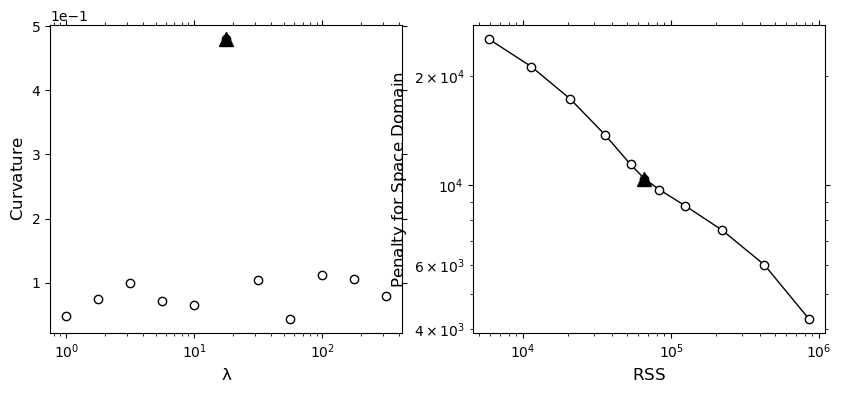

In [28]:
# curvature
fig = plt.figure(figsize = (10, 4))
fig.subplots_adjust(wspace=0.4)

ax = fig.add_subplot(121)
ax.semilogx(lams_s, calcCurvature2(np.log(rss2_1), np.log(nrm2_1)), "o", ms=6, color='#000000',markerfacecolor='#ffffff', linewidth = 1)

num_opt_1 = np.argmax(calcCurvature2(np.log(rss2_1), np.log(nrm2_1)))

ax.semilogx(lams_s[num_opt_1], calcCurvature2(np.log(rss2_1), np.log(nrm2_1))[num_opt_1], '^', ms=10, color = "black")
ax.set_xlabel(r'${\rm \lambda_s}$', fontsize = 12)
ax.set_ylabel(r'${\rm Curvature}$', fontsize = 12)

ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')

#ax.set_xticks([0, 1e5, 2e5, 3e5])
#ax.ticklabel_format(style="sci",  axis="x",scilimits=(0,0))
ax.ticklabel_format(style="sci",  axis="y", scilimits=(0,0))

#ax.set_xlim(2e-2, 5e2)
#ax.set_ylim(-0.5, 6.5)

ax = fig.add_subplot(122)
ax.loglog(rss2_1, nrm2_1, 'o-', ms=6, color='#000000', markerfacecolor='#ffffff', linewidth = 1)
ax.loglog(rss2_1[num_opt_1], nrm2_1[num_opt_1], '^', ms=10, color = "black")
ax.set_xlabel(r'$\text{RSS}$', fontsize = 12)
ax.set_ylabel(r'$\text{Penalty for Space Domain}$', fontsize = 12)
#ax.set_xlim(1e3, 13e4)
#ax.set_ylim(2e3, 3e4)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')

In [29]:
print("optimal lambda_s = {}".format(lams_s[num_opt_1]))

optimal lambda_s = 17.78279410038923


### Step.2

In [30]:
# hyper-parameters
lams_t = np.power(10., np.arange(0.0, 2.6, 0.25))
print("lams2 = {}".format(lams_t))

lams2 = [  1.           1.77827941   3.16227766   5.62341325  10.
  17.7827941   31.6227766   56.23413252 100.         177.827941
 316.22776602]


In [31]:
%%time
params_all = []
betas1_all = []
betas2_all = []
betas3_all = []
betas4_all = []

for lit in range(len(lams_t)):

    params_all.append([lams_s[num_opt_1], lams_t[lit]])
    print("lm1 = {}, lm2 = {}".format(lams_s[num_opt_1], lams_t[lit]))

    model = admm_group_lasso(lambda_s = lams_s[num_opt_1], lambda_t = lams_t[lit], alpha = alpha, rho = rho, eta = eta, tol = 1.e-3)
    model.fit(fobs, Z, D, inv1, inv2, times = 4, num_of_cells = nx*ny*nz)
    
    beta_sim1 = model.beta_[0*nx*ny*nz:1*nx*ny*nz] / w1
    beta_sim2 = model.beta_[1*nx*ny*nz:2*nx*ny*nz] / w2
    beta_sim3 = model.beta_[2*nx*ny*nz:3*nx*ny*nz] / w3
    beta_sim4 = model.beta_[3*nx*ny*nz:4*nx*ny*nz] / w4

    betas1_all.append(beta_sim1)
    betas2_all.append(beta_sim2)
    betas3_all.append(beta_sim3)
    betas4_all.append(beta_sim4)

# ndarry
params_all = np.array(params_all)
betas1_all = np.array(betas1_all)
betas2_all = np.array(betas2_all)
betas3_all = np.array(betas3_all)
betas4_all = np.array(betas4_all)

lm1 = 17.78279410038923, lm2 = 1.0
iter = 0, delta = 0.31451181446794296
fin_i = 699
lm1 = 17.78279410038923, lm2 = 1.7782794100389228
iter = 0, delta = 0.31451181446794296
fin_i = 661
lm1 = 17.78279410038923, lm2 = 3.1622776601683795
iter = 0, delta = 0.31451181446794296
fin_i = 624
lm1 = 17.78279410038923, lm2 = 5.623413251903491
iter = 0, delta = 0.31451181446794296
fin_i = 606
lm1 = 17.78279410038923, lm2 = 10.0
iter = 0, delta = 0.31451181446794296
fin_i = 607
lm1 = 17.78279410038923, lm2 = 17.78279410038923
iter = 0, delta = 0.31451181446794296
fin_i = 618
lm1 = 17.78279410038923, lm2 = 31.622776601683793
iter = 0, delta = 0.31451181446794296
fin_i = 655
lm1 = 17.78279410038923, lm2 = 56.23413251903491
iter = 0, delta = 0.31451181446794296
fin_i = 782
lm1 = 17.78279410038923, lm2 = 100.0
iter = 0, delta = 0.31451181446794296
iter = 1000, delta = 0.001451967385618218
fin_i = 1304
lm1 = 17.78279410038923, lm2 = 177.82794100389228
iter = 0, delta = 0.31451181446794296
iter = 1000, d

In [32]:
import pickle
with open('Params_case_2_2_new_4d-2.pickle', 'wb') as f:
    pickle.dump(params_all, f)
with open('Betas1_case_2_2_new_4d-2.pickle', 'wb') as f:
    pickle.dump(betas1_all, f)
with open('Betas2_case_2_2_new_4d-2.pickle', 'wb') as f:
    pickle.dump(betas2_all, f)
with open('Betas3_case_2_2_new_4d-2.pickle', 'wb') as f:
    pickle.dump(betas3_all, f)
with open('Betas4_case_2_2_new_4d-2.pickle', 'wb') as f:
    pickle.dump(betas4_all, f)

In [33]:
# L-curve
rss2_2 = []
nrm2_2 = []

for lit in range(len(lams_t)):
    
    betas_temp = np.r_[betas1_all[lit]*w1, betas2_all[lit]*w2, betas3_all[lit]*w3, betas4_all[lit]*w4]
    rss_temp = misfit(fobs, Z, betas_temp)
    pen_temp = pen2(D*betas_temp, nx*ny*nz, 4)
    
    rss2_2.append(rss_temp)
    nrm2_2.append(pen_temp)
    print(rss_temp, pen_temp)

65928.1596280294 1318.9926007603995
65980.80944906325 1140.2520940698955
66052.24125750492 995.5164908092117
66138.8689823426 877.8028044024835
66276.54103077814 792.6118514286433
66575.91006897675 726.9939814435427
67239.9330653987 677.0190646638121
68685.8990376746 627.8964267479153
71923.46218113527 548.6328713224591
78371.57476931793 462.8843212040749
91576.6158718163 366.83958289726655


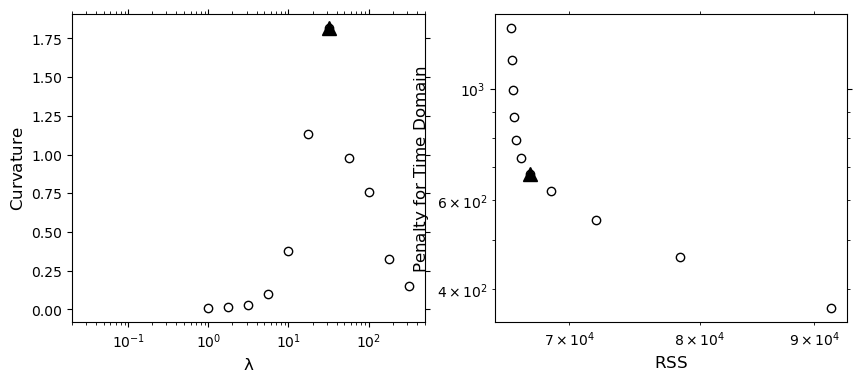

In [36]:
# curvature
fig = plt.figure(figsize = (10, 4))

ax = fig.add_subplot(121)
ax.semilogx(lams_t, calcCurvature2(np.log(rss2_2), np.log(nrm2_2)), "o", ms=6, color='k',markerfacecolor='#ffffff', linewidth = 1)

num_opt_2 = np.argmax(calcCurvature2(np.log(rss2_2), np.log(nrm2_2)))

ax.semilogx(lams_t[num_opt_2], calcCurvature2(np.log(rss2_2), np.log(nrm2_2))[num_opt_2], '^', ms=10, color = "black")
ax.set_xlabel(r'${\rm \lambda_t}$', fontsize = 12)
ax.set_ylabel(r'${\rm Curvature}$', fontsize = 12)

ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')

#ax.set_xticks([0, 1e5, 2e5, 3e5])
#ax.ticklabel_format(style="sci",  axis="x",scilimits=(0,0))
ax.ticklabel_format(style="sci",  axis="y",scilimits=(0,0))

#ax.set_xlim(2e-2, 5e2)
#ax.set_ylim(-0.1, 0.65)

ax = fig.add_subplot(122)
ax.loglog(rss2_2, nrm2_2, 'o', ms=6, color='k', markerfacecolor='#ffffff', linewidth = 1)
ax.loglog(rss2_2[num_opt_2], nrm2_2[num_opt_2], '^', ms=10, color = "black")

ax.set_xlabel(r'$\text{RSS}$', fontsize = 12)
ax.set_ylabel(r'$\text{Penalty for Time Domain}$', fontsize = 12)
#ax.set_xlim(3.16e4, 3.23e4)
#ax.set_ylim(6e1, 5e2)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')

In [37]:
print("optimal lambda_t = {}".format(lams_t[num_opt_2]))

optimal lambda_t = 31.622776601683793


### Step.3

In [38]:
# hyper-parameters
lams_s = np.power(10., np.arange(0.0, 2.6, 0.25))
print("lams_s = {}".format(lams_s))

lams_s = [  1.           1.77827941   3.16227766   5.62341325  10.
  17.7827941   31.6227766   56.23413252 100.         177.827941
 316.22776602]


In [39]:
%%time
params_all = []
betas1_all = []
betas2_all = []
betas3_all = []
betas4_all = []

for lis in range(len(lams_s)):

    params_all.append([lams_s[lis], lams_t[num_opt_2]])
    print("lm1 = {}, lm2 = {}".format(lams_s[lis], lams_t[num_opt_2]))

    model = admm_group_lasso(lambda_s = lams_s[lis], lambda_t = lams_t[num_opt_2], alpha = alpha, rho = rho, eta = eta, tol = 1.e-3)
    model.fit(fobs, Z, D, inv1, inv2, times = 4, num_of_cells = nx*ny*nz)
    
    beta_sim1 = model.beta_[0*nx*ny*nz:1*nx*ny*nz] / w1
    beta_sim2 = model.beta_[1*nx*ny*nz:2*nx*ny*nz] / w2
    beta_sim3 = model.beta_[2*nx*ny*nz:3*nx*ny*nz] / w3
    beta_sim4 = model.beta_[3*nx*ny*nz:4*nx*ny*nz] / w4

    betas1_all.append(beta_sim1)
    betas2_all.append(beta_sim2)
    betas3_all.append(beta_sim3)
    betas4_all.append(beta_sim4)

# ndarry
params_all = np.array(params_all)
betas1_all = np.array(betas1_all)
betas2_all = np.array(betas2_all)
betas3_all = np.array(betas3_all)
betas4_all = np.array(betas4_all)

lm1 = 1.0, lm2 = 31.622776601683793
iter = 0, delta = 0.18840644569583165
iter = 1000, delta = 0.001165694035279753
fin_i = 1109
lm1 = 1.7782794100389228, lm2 = 31.622776601683793
iter = 0, delta = 0.23313718272342382
iter = 1000, delta = 0.0012471240832160045
fin_i = 1177
lm1 = 3.1622776601683795, lm2 = 31.622776601683793
iter = 0, delta = 0.2690773446367532
iter = 1000, delta = 0.0012814285961266303
fin_i = 1205
lm1 = 5.623413251903491, lm2 = 31.622776601683793
iter = 0, delta = 0.2944147511925045
iter = 1000, delta = 0.00119104232988223
fin_i = 1148
lm1 = 10.0, lm2 = 31.622776601683793
iter = 0, delta = 0.3095544593360817
fin_i = 791
lm1 = 17.78279410038923, lm2 = 31.622776601683793
iter = 0, delta = 0.31451181446794296
fin_i = 655
lm1 = 31.622776601683793, lm2 = 31.622776601683793
iter = 0, delta = 0.3145375846173771
iter = 1000, delta = 0.0010323978125118818
fin_i = 1030
lm1 = 56.23413251903491, lm2 = 31.622776601683793
iter = 0, delta = 0.3145375846173771
iter = 1000, delta = 0.0

In [40]:
import pickle
with open('Params_case_2_2_new_4d-3.pickle', 'wb') as f:
    pickle.dump(params_all, f)
with open('Betas1_case_2_2_new_4d-3.pickle', 'wb') as f:
    pickle.dump(betas1_all, f)
with open('Betas2_case_2_2_new_4d-3.pickle', 'wb') as f:
    pickle.dump(betas2_all, f)
with open('Betas3_case_2_2_new_4d-3.pickle', 'wb') as f:
    pickle.dump(betas3_all, f)
with open('Betas4_case_2_2_new_4d-3.pickle', 'wb') as f:
    pickle.dump(betas4_all, f)

In [41]:
# L-curve
rss2_3 = []
nrm2_3 = []

for lis in range(len(lams_s)):
    
    betas_temp = np.r_[betas1_all[lis]*w1, betas2_all[lis]*w2, betas3_all[lis]*w3, betas4_all[lis]*w4]
    rss_temp = misfit(fobs, Z, betas_temp)
    pen_temp = pen1(betas_temp, alpha = 0.9)
    
    rss2_3.append(rss_temp)
    nrm2_3.append(pen_temp)

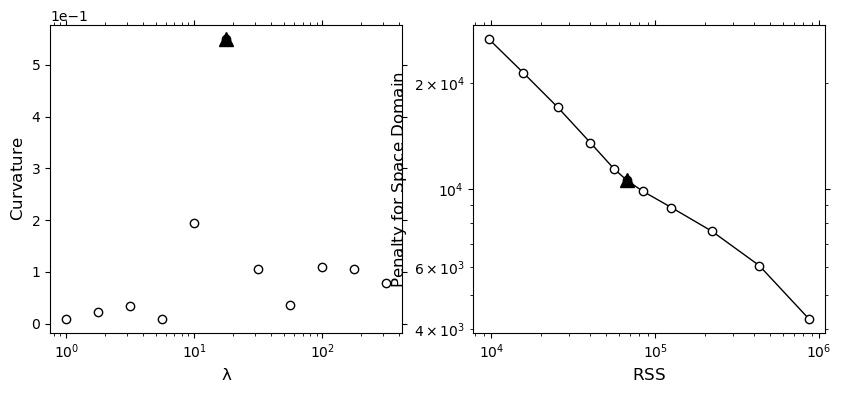

In [44]:
# curvature
fig = plt.figure(figsize = (10, 4))

ax = fig.add_subplot(121)
ax.semilogx(lams_s, calcCurvature2(np.log(rss2_3), np.log(nrm2_3)), "o", ms=6, color='#000000',markerfacecolor='#ffffff', linewidth = 1)

num_opt3 = np.argmax(calcCurvature2(np.log(rss2_3), np.log(nrm2_3)))

ax.semilogx(lams_s[num_opt3], calcCurvature2(np.log(rss2_3), np.log(nrm2_3))[num_opt3], '^', ms=10, color = "black")
ax.set_xlabel(r'${\rm \lambda_s}$', fontsize = 12)
ax.set_ylabel(r'${\rm Curvature}$', fontsize = 12)

ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')

#ax.set_xticks([0, 1e5, 2e5, 3e5])
#ax.ticklabel_format(style="sci",  axis="x",scilimits=(0,0))
ax.ticklabel_format(style="sci",  axis="y",scilimits=(0,0))

#ax.set_xlim(2e-2, 5e2)
#ax.set_ylim(-0.5, 5.5)

ax = fig.add_subplot(122)
ax.loglog(rss2_3, nrm2_3, 'o-', ms=6, color='#000000', markerfacecolor='#ffffff', linewidth = 1)
ax.loglog(rss2_3[num_opt3], nrm2_3[num_opt3], '^', ms=10, color = "black")
ax.set_xlabel(r'$\text{RSS}$', fontsize = 12)
ax.set_ylabel(r'$\text{Penalty for Space Domain}$', fontsize = 12)
#ax.set_xlim(5e3, 13e4)
#ax.set_ylim(2e3, 7e4)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')

In [45]:
print("optimal lambda_s = {}".format(lams_s[num_opt3]))

optimal lambda_s = 17.78279410038923
